# 3. EDA: Exploratory Data Analysis
**Project:** HR Analytics: Employee Attrition

---

## Overview
Exploratory analysis covering univariate distributions, feature-vs-target relationships, and multivariate interactions.

## Contents
1. Setup
2. Numeric Feature Distributions
3. Categorical Feature Distributions
4. Feature vs. Target (Bivariate)
5. Multivariate Analysis
6. Key Business Insights

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
import sys
sys.path.append('..')
from src.viz_utils import set_style

warnings.filterwarnings('ignore')
set_style()

PALETTE = {'0 - Staying': '#4C9BE8', '1 - Seeking': '#E87B4C'}

train = pd.read_csv('../data/raw/aug_train.csv')
train['target_label'] = train['target'].map({0: '0 - Staying', 1: '1 - Seeking'})
print('Loaded:', train.shape)

Loaded: (19158, 15)


## 2. Numeric Feature Distributions

### `training_hours`: raw vs. log-transformed
Let's check if training investment roughly even or if a few candidates dominate.

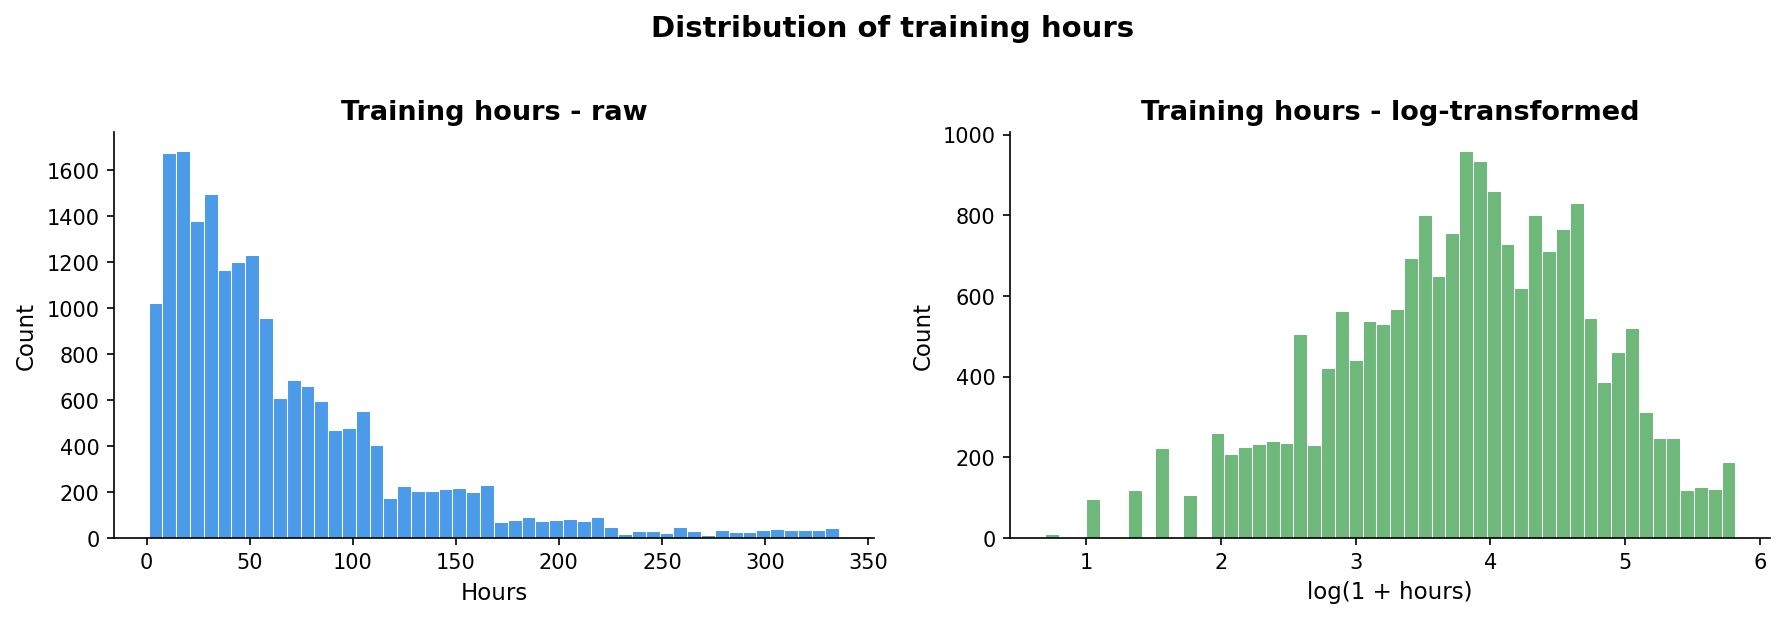

Skew (raw): 1.82
Skew (log): -0.35


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['training_hours'], bins=50,
             color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].set_title('Training hours - raw')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(train['training_hours']), bins=50,
             color='#6DB87A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Training hours - log-transformed')
axes[1].set_xlabel('log(1 + hours)')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution of training hours', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_training_hours_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Skew (raw): {train["training_hours"].skew():.2f}')
print(f'Skew (log): {np.log1p(train["training_hours"]).skew():.2f}')

Raw `training_hours` is right-skewed (skew = 1.82). The log-transform brings it to -0.35, near-normal. So, we will use `log1p(training_hours)` in all modeling and visualizations.

### `city_development_index`: distribution and bimodality

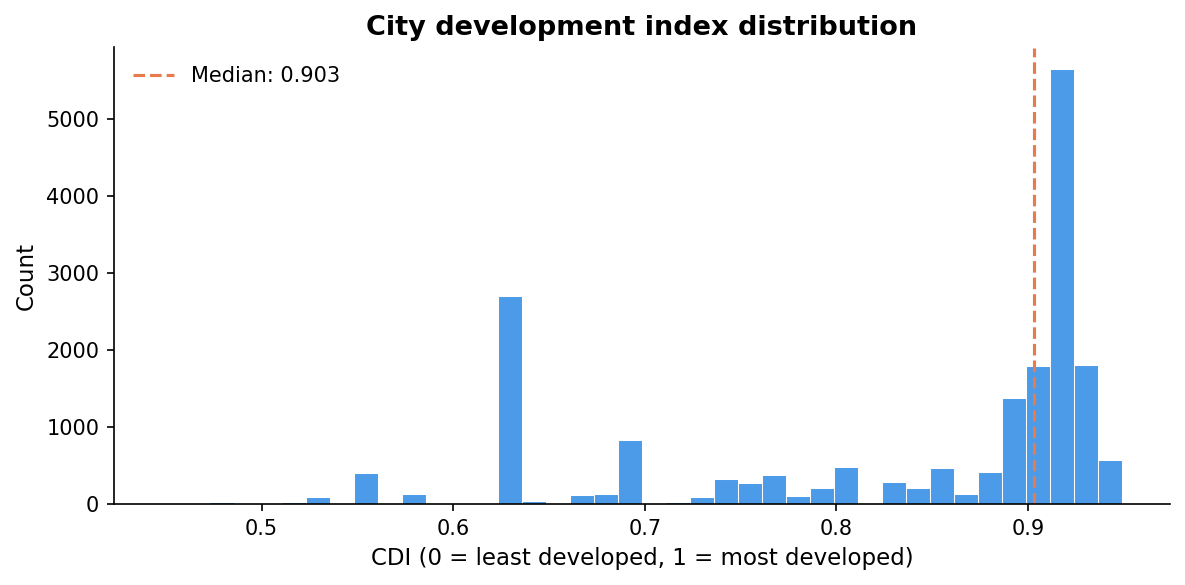

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train['city_development_index'], bins=40,
        color='#4C9BE8', edgecolor='white', linewidth=0.5)
ax.axvline(train['city_development_index'].median(),
           color='#E87B4C', linestyle='--', linewidth=1.5,
           label=f'Median: {train["city_development_index"].median():.3f}')
ax.set_title('City development index distribution')
ax.set_xlabel('CDI (0 = least developed, 1 = most developed)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/03_city_development_index.png', bbox_inches='tight', dpi=150)
plt.show()

Bimodal distribution - large cluster near CDI ~0.92 (major urban centers), smaller cluster at lower CDI values (smaller cities). This bimodality will drive a strong separation in the attrition analysis.

## 3. Categorical Feature Distributions

### Categorical features overview

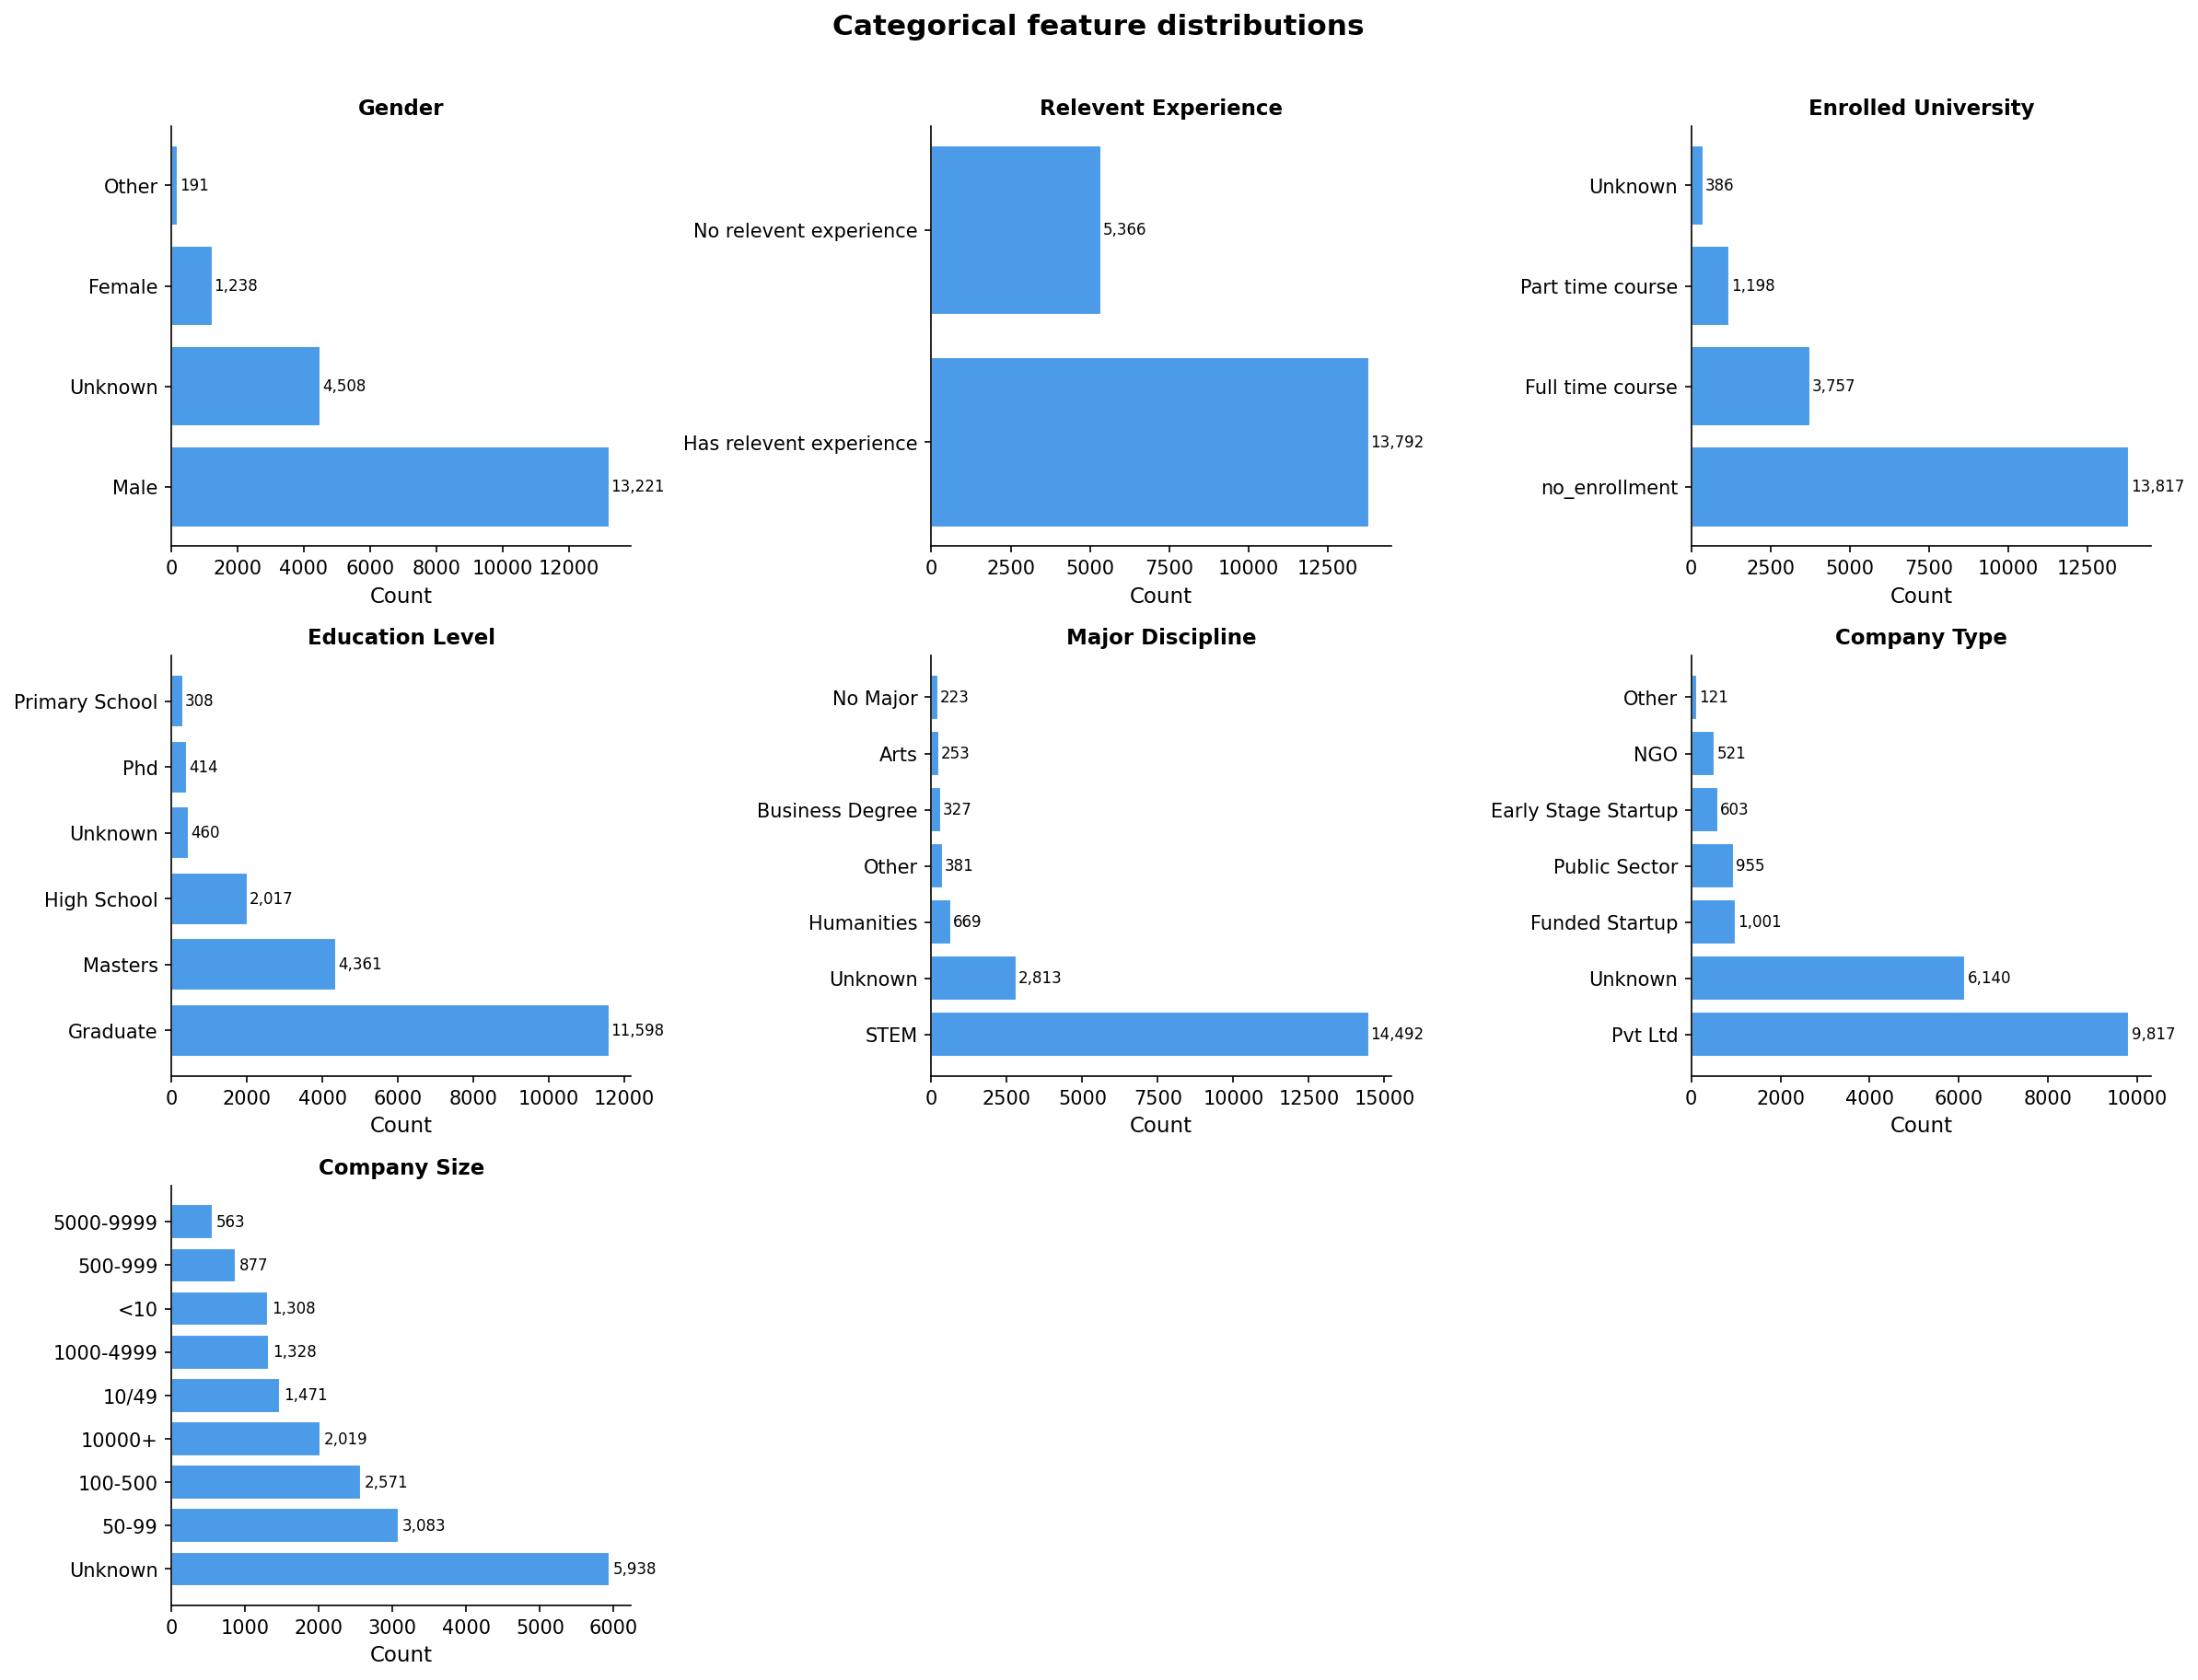

In [4]:
cat_cols = ['gender', 'relevent_experience', 'enrolled_university',
            'education_level', 'major_discipline', 'company_type', 'company_size']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = train[col].fillna('Unknown').value_counts()
    axes[i].barh(counts.index, counts.values, color='#4C9BE8', edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 50, j, f'{v:,}', va='center', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical feature distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/04_categorical_overview.png', bbox_inches='tight', dpi=150)
plt.show()

**Key observations:**
- `relevent_experience`: ~72% have relevant experience - strong imbalance within the feature
- `major_discipline`: STEM dominates (~89% of non-missing); 'No Major' and 'Arts' are rare
- `company_type`: Private Ltd dominates; Unknown (missing) is a major category at ~32%
- `company_size`: '50-99' is most common; '10/49' and '10-49' are the same band (formatting issue)
- `education_level`: Graduate is the modal category by a large margin
- `enrolled_university`: Most candidates are not currently enrolled

### Experience: ordinal distribution with correct sort

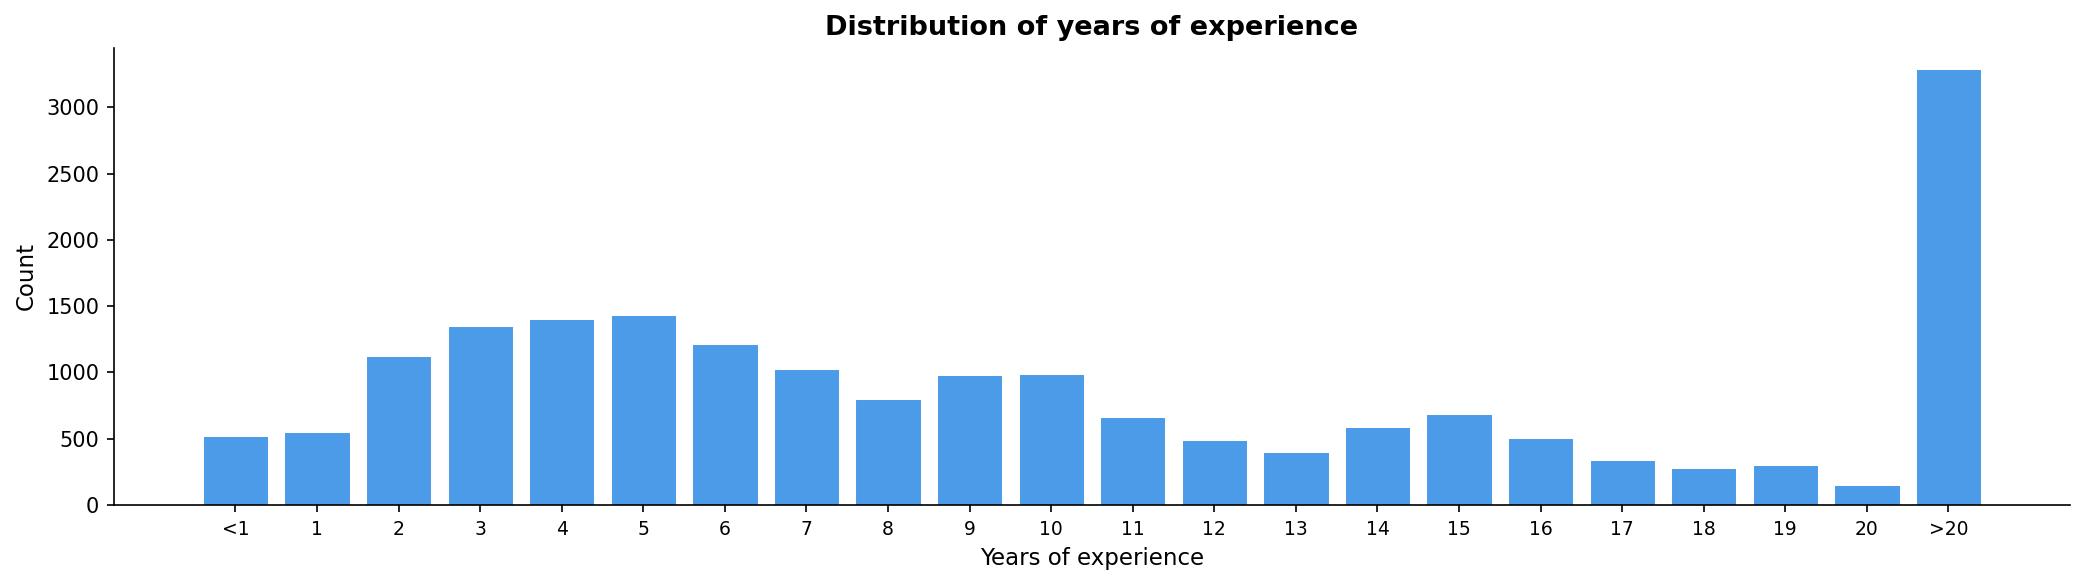

In [5]:
exp_order = ['<1','1','2','3','4','5','6','7','8','9','10',
             '11','12','13','14','15','16','17','18','19','20','>20']

exp_counts = (train['experience'].value_counts()
                                 .reindex([e for e in exp_order
                                           if e in train['experience'].values]))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(exp_counts)), exp_counts.values,
       color='#4C9BE8', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(exp_counts)))
ax.set_xticklabels(exp_counts.index, fontsize=9)
ax.set_title('Distribution of years of experience')
ax.set_xlabel('Years of experience')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/04b_experience_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

Experience peaks at mid-career (5–10 years). The >20 bucket is the single largest bar but acts as a catch-all for all senior candidates, so it does not represent one discrete cohort. Early-career (<3 years) candidates are less represented, which means their attrition rates in the bivariate analysis will be noisier.

## 4. Feature vs. Target

### City Development Index vs. Target
Do candidates from less-developed cities seek job changes more?
**Hypothesis:** Lower CDI = limited local opportunities = higher incentive to leave.

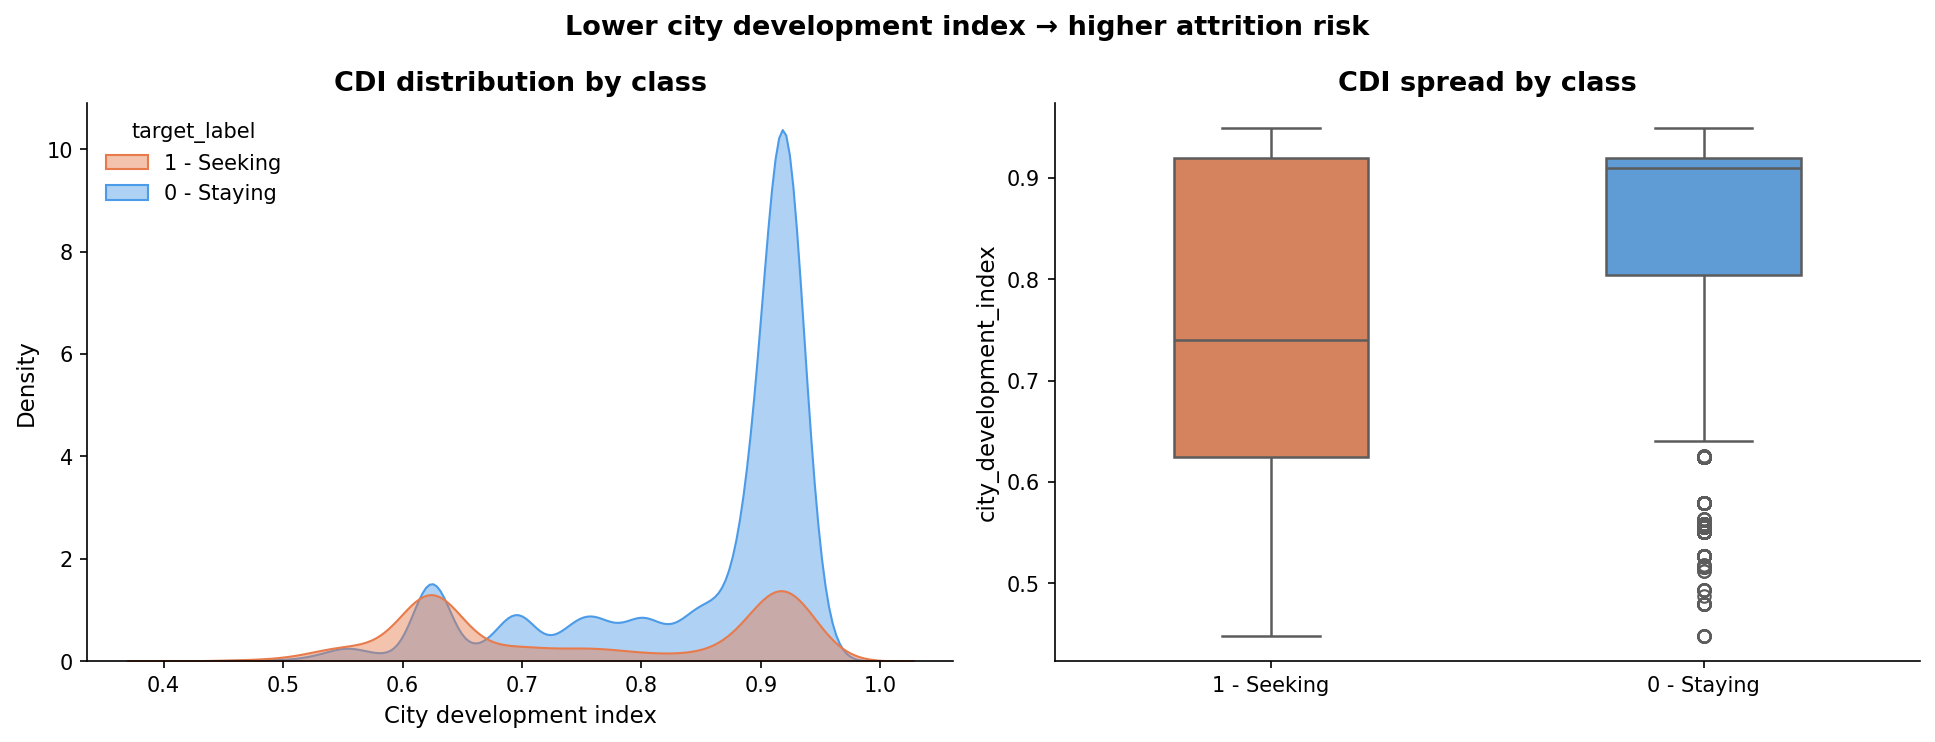

Median CDI by target:
target
0.0    0.91
1.0    0.74
Name: city_development_index, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.kdeplot(data=train, x='city_development_index',
            hue='target_label', palette=PALETTE,
            fill=True, alpha=0.45, ax=axes[0])
sns.move_legend(axes[0], "upper left")
axes[0].set_title('CDI distribution by class')
axes[0].set_xlabel('City development index')
axes[0].set_ylabel('Density')

sns.boxplot(data=train, x='target_label', y='city_development_index',
            hue='target_label', palette=PALETTE,
            ax=axes[1], width=0.45, linewidth=1.2, legend=False)
axes[1].set_title('CDI spread by class')
axes[1].set_xlabel('')

plt.suptitle('Lower city development index → higher attrition risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_cdi_vs_target.png', bbox_inches='tight', dpi=150)
plt.show()

print('Median CDI by target:')
print(train.groupby('target')['city_development_index'].median())

Job-seekers have a meaningfully lower median CDI (~0.74) compared to non-seekers (~0.91). The KDE shows a heavier tail at low CDI values for the seeking class. This is the **strongest single predictor** of attrition risk in the dataset.

### Experience vs. Target
At which career stage is the flight risk highest?

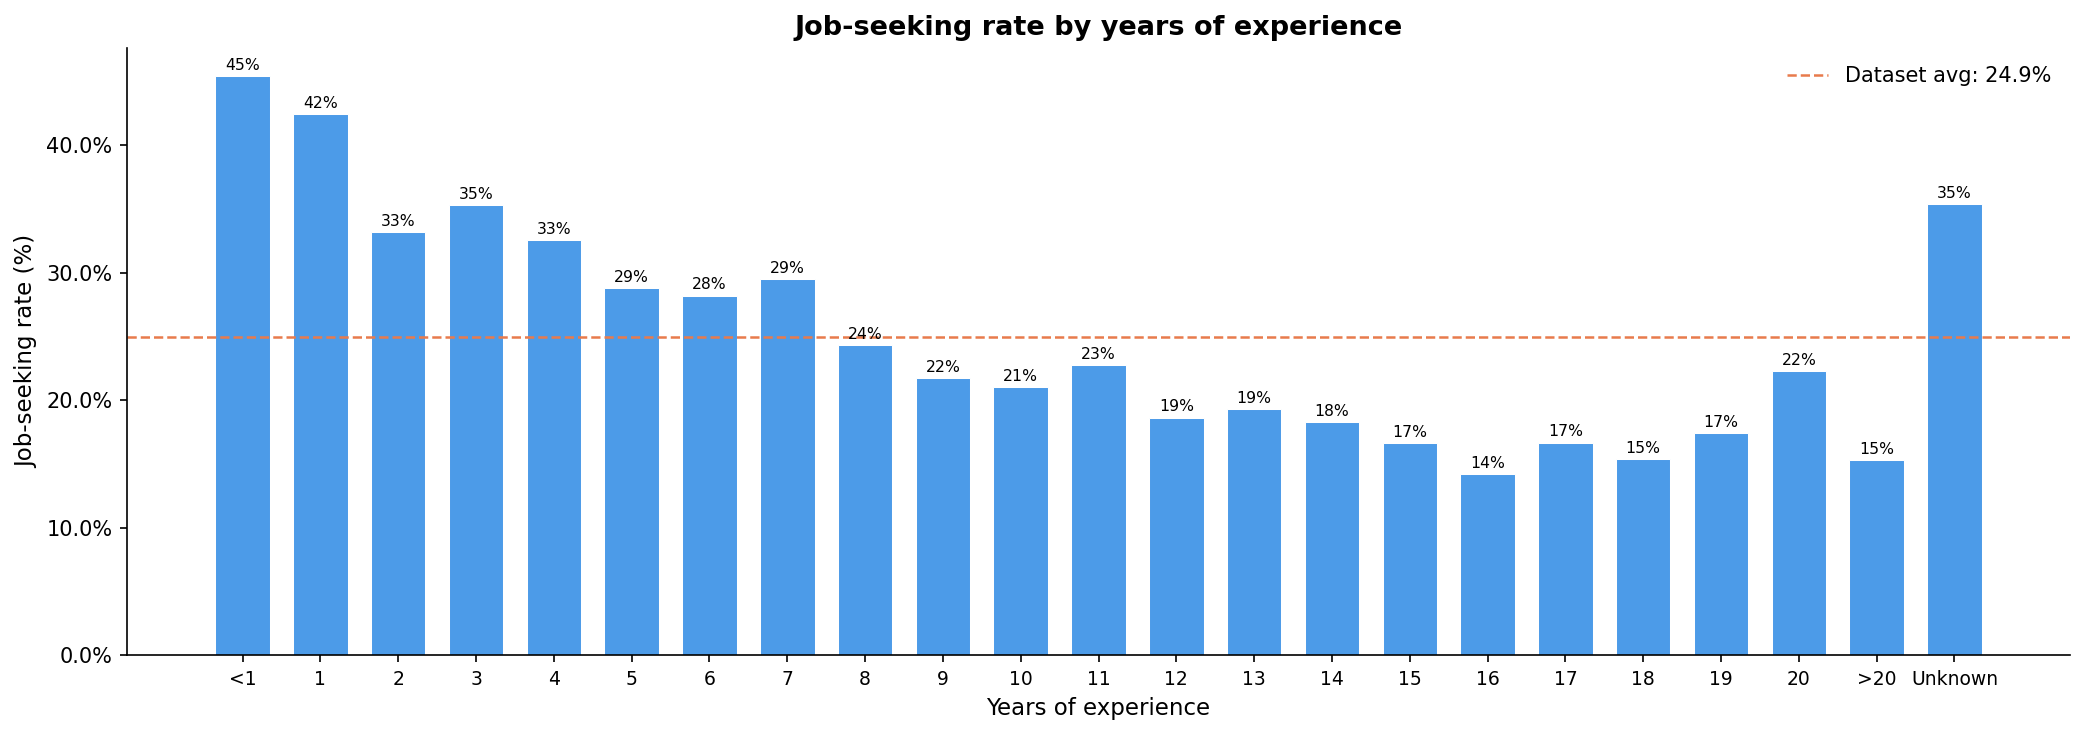

In [7]:
exp_order = ['<1','1','2','3','4','5','6','7','8','9','10',
             '11','12','13','14','15','16','17','18','19','20','>20']

exp_rate = (
    train.assign(experience=pd.Categorical(
        train['experience'].fillna('Unknown'),
        categories=exp_order + ['Unknown'], ordered=True))
    .groupby('experience', observed=True)['target']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(exp_rate)), exp_rate.values,
              color='#4C9BE8', edgecolor='white', linewidth=0.5, width=0.7)
ax.set_xticks(range(len(exp_rate)))
ax.set_xticklabels(exp_rate.index, fontsize=9)
ax.set_title('Job-seeking rate by years of experience')
ax.set_xlabel('Years of experience')
ax.set_ylabel('Job-seeking rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(train['target'].mean() * 100, color='#E87B4C',
           linestyle='--', linewidth=1.2,
           label=f'Dataset avg: {train["target"].mean()*100:.1f}%')
ax.legend()
for bar, v in zip(bars, exp_rate.values):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                f'{v:.0f}%', ha='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('../outputs/figures/06_experience_vs_target.png', bbox_inches='tight', dpi=150)
plt.show()

Attrition intent peaks at **1–4 years** of experience (~30–45% seeking rate) and declines steadily from year 5. By 15+ years, seeking rate drops below 18%. The 2–3 year mark is the **critical retention window** - enough skill to be marketable externally, not enough organizational ties to stay.

### Company Size vs. Target

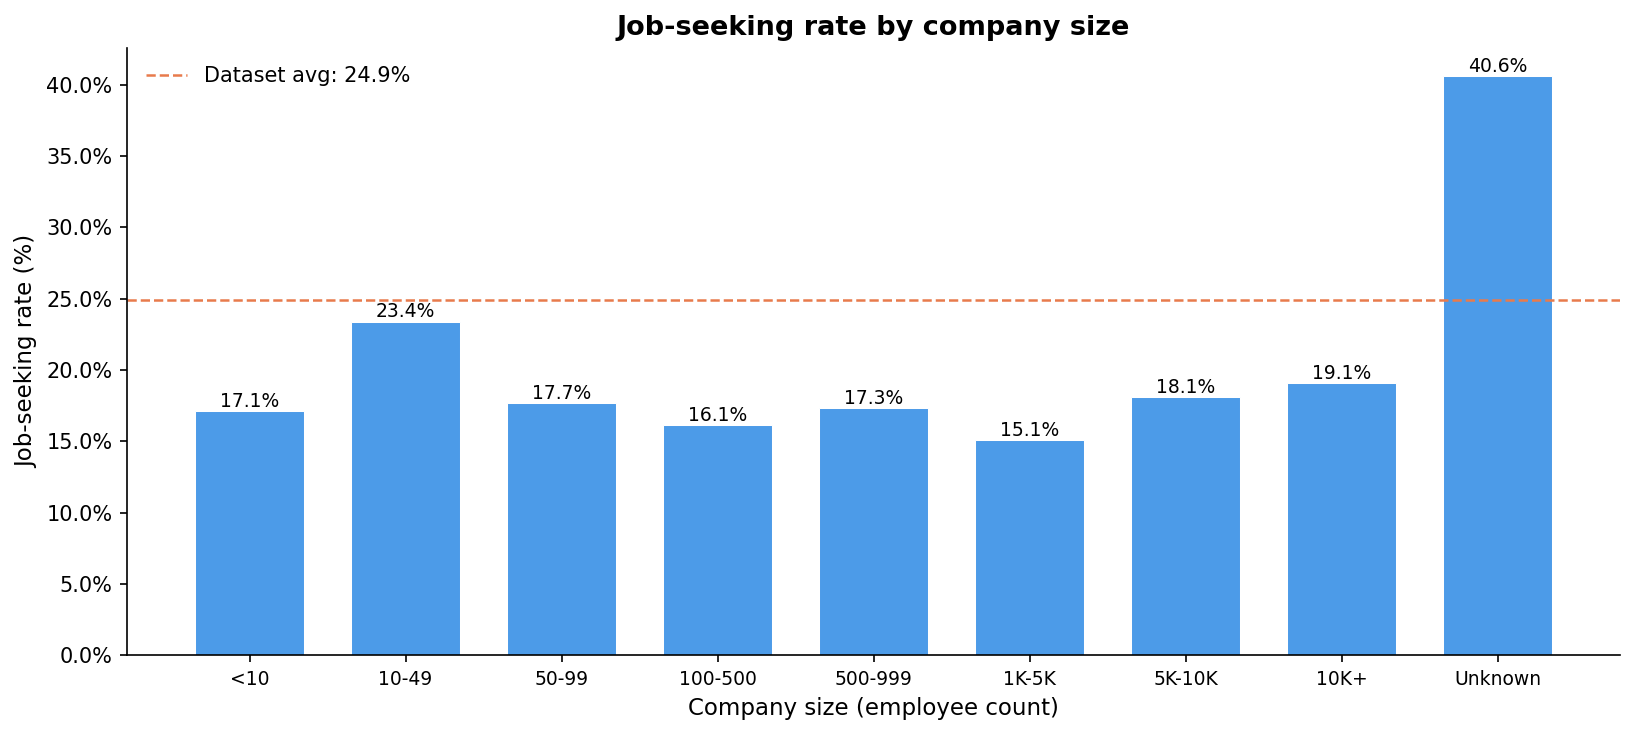

In [8]:
size_order = ['<10','10/49','50-99','100-500','500-999',
              '1000-4999','5000-9999','10000+','Unknown']

size_rate = (
    train.assign(company_size=train['company_size'].fillna('Unknown'))
    .groupby('company_size')['target']
    .mean() * 100
)
size_rate = size_rate.reindex(
    [s for s in size_order if s in size_rate.index]
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(size_rate)), size_rate.values,
              color='#4C9BE8', edgecolor='white', linewidth=0.5, width=0.7)
ax.set_xticks(range(len(size_rate)))
size_label_map = {
    '<10': '<10', '10/49': '10-49', '50-99': '50-99',
    '100-500': '100-500', '500-999': '500-999',
    '1000-4999': '1K-5K', '5000-9999': '5K-10K',
    '10000+': '10K+', 'Unknown': 'Unknown'
}
ax.set_xticklabels(
    [size_label_map.get(s, s) for s in size_rate.index],
    fontsize=9
)
ax.set_title('Job-seeking rate by company size')
ax.set_xlabel('Company size (employee count)')
ax.set_ylabel('Job-seeking rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(train['target'].mean() * 100, color='#E87B4C',
           linestyle='--', linewidth=1.2,
           label=f'Dataset avg: {train["target"].mean()*100:.1f}%')
ax.legend()
for bar, v in zip(bars, size_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
            f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/07_company_size_vs_target.png', bbox_inches='tight', dpi=150)
plt.show()

Very small companies (<10) and the Unknown group show attrition rates above 35%. Enterprise employees (10,000+) are the most stable (<20%). Company size acts as a **proxy for job security** - smaller employers carry higher perceived instability. The Unknown group (likely freelancers) shows the highest rate overall at ~41%.

### Last New Job vs. Target
**Business question:** Does time since the last job change predict attrition intent?

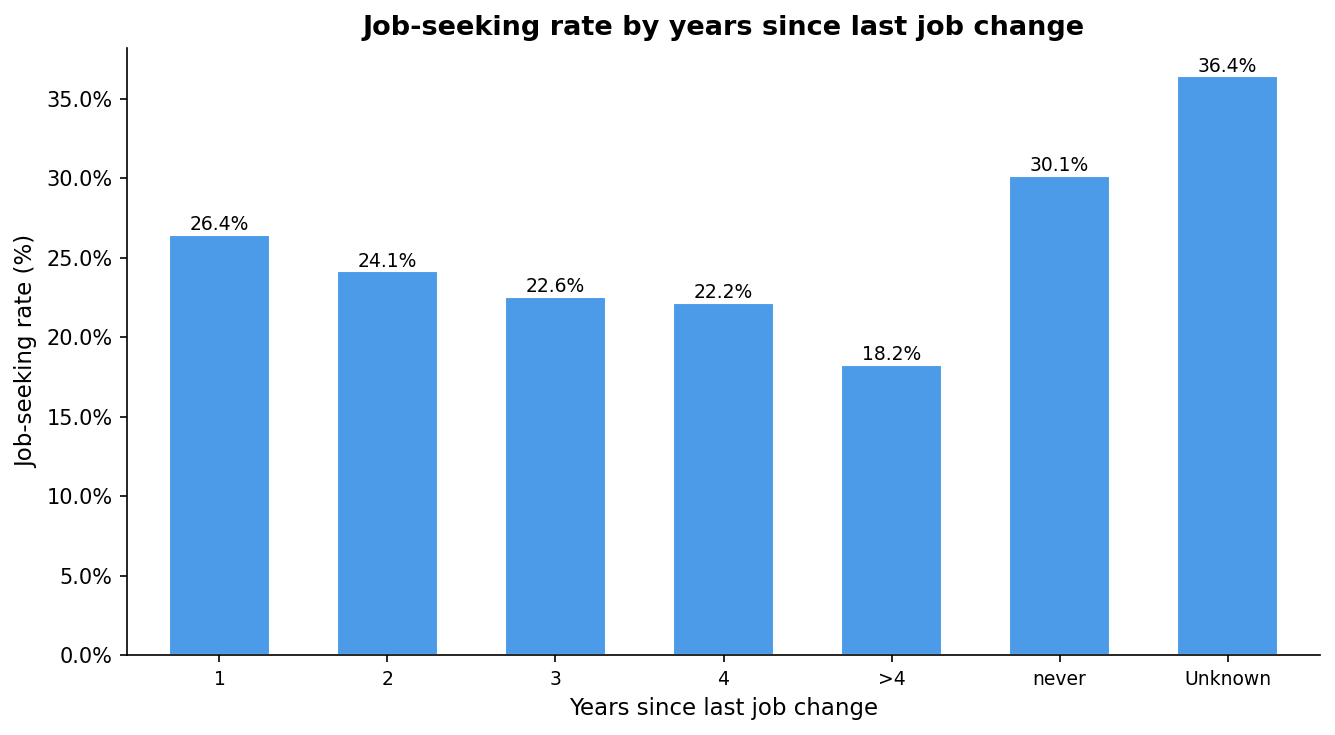

In [9]:
lnj_order = ['1', '2', '3', '4', '>4', 'never']

lnj_data = (
    train.assign(last_new_job=train['last_new_job'].fillna('Unknown'))
    .groupby(['last_new_job', 'target_label'])
    .size()
    .unstack(fill_value=0)
)
lnj_rate = lnj_data.div(lnj_data.sum(axis=1), axis=0) * 100
lnj_rate = lnj_rate.reindex(
    [s for s in lnj_order + ['Unknown'] if s in lnj_rate.index]
)

fig, ax = plt.subplots(figsize=(9, 5))
lnj_rate['1 - Seeking'].plot(kind='bar', ax=ax,
                              color='#4C9BE8', edgecolor='white', width=0.6)
ax.set_title('Job-seeking rate by years since last job change')
ax.set_xlabel('Years since last job change')
ax.set_ylabel('Job-seeking rate (%)')
ax.set_xticklabels(lnj_rate.index, fontsize=9, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/08_last_new_job_vs_target.png', bbox_inches='tight', dpi=150)
plt.show()

Seeking rate generally declines with time since the last job change (26.4% at 1 year → 18.2% at >4 years). One notable exception: candidates who have **never** changed jobs show an elevated rate of 30.1%, likely because they are in their first role and now testing the market for the first time.

### Training Hours vs. Target
**Business question:** Does more training correlate with higher or lower attrition intent?

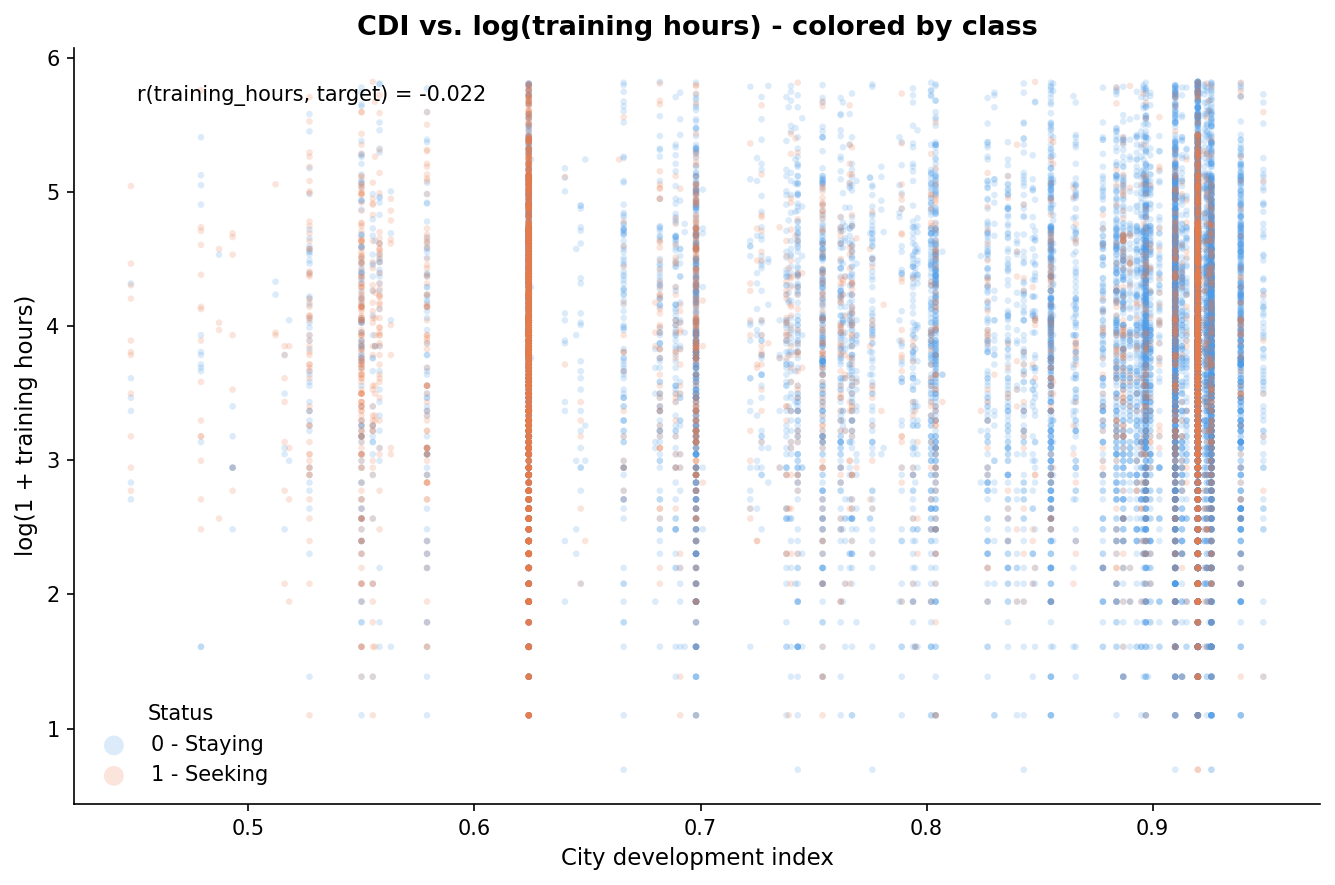

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, group in train.groupby('target_label'):
    ax.scatter(group['city_development_index'],
               np.log1p(group['training_hours']),
               c=PALETTE[label],
               alpha=0.2, s=10, label=label, edgecolors='none')
ax.set_title('CDI vs. log(training hours) - colored by class')
ax.set_xlabel('City development index')
ax.set_ylabel('log(1 + training hours)')
ax.legend(title='Status', markerscale=3)

corr = train[['training_hours', 'target']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r(training_hours, target) = {corr:.3f}',
        transform=ax.transAxes, fontsize=10, va='top')
plt.tight_layout()
plt.savefig('../outputs/figures/09_cdi_training_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

Training hours are virtually uncorrelated with attrition intent (r ≈ 0.01). The scatter confirms complete class overlap at all training levels. **Upskilling is not a retention signal** - it captures motivation to learn, not motivation to stay.

## 5. Multivariate Analysis

### Correlation Heatmap

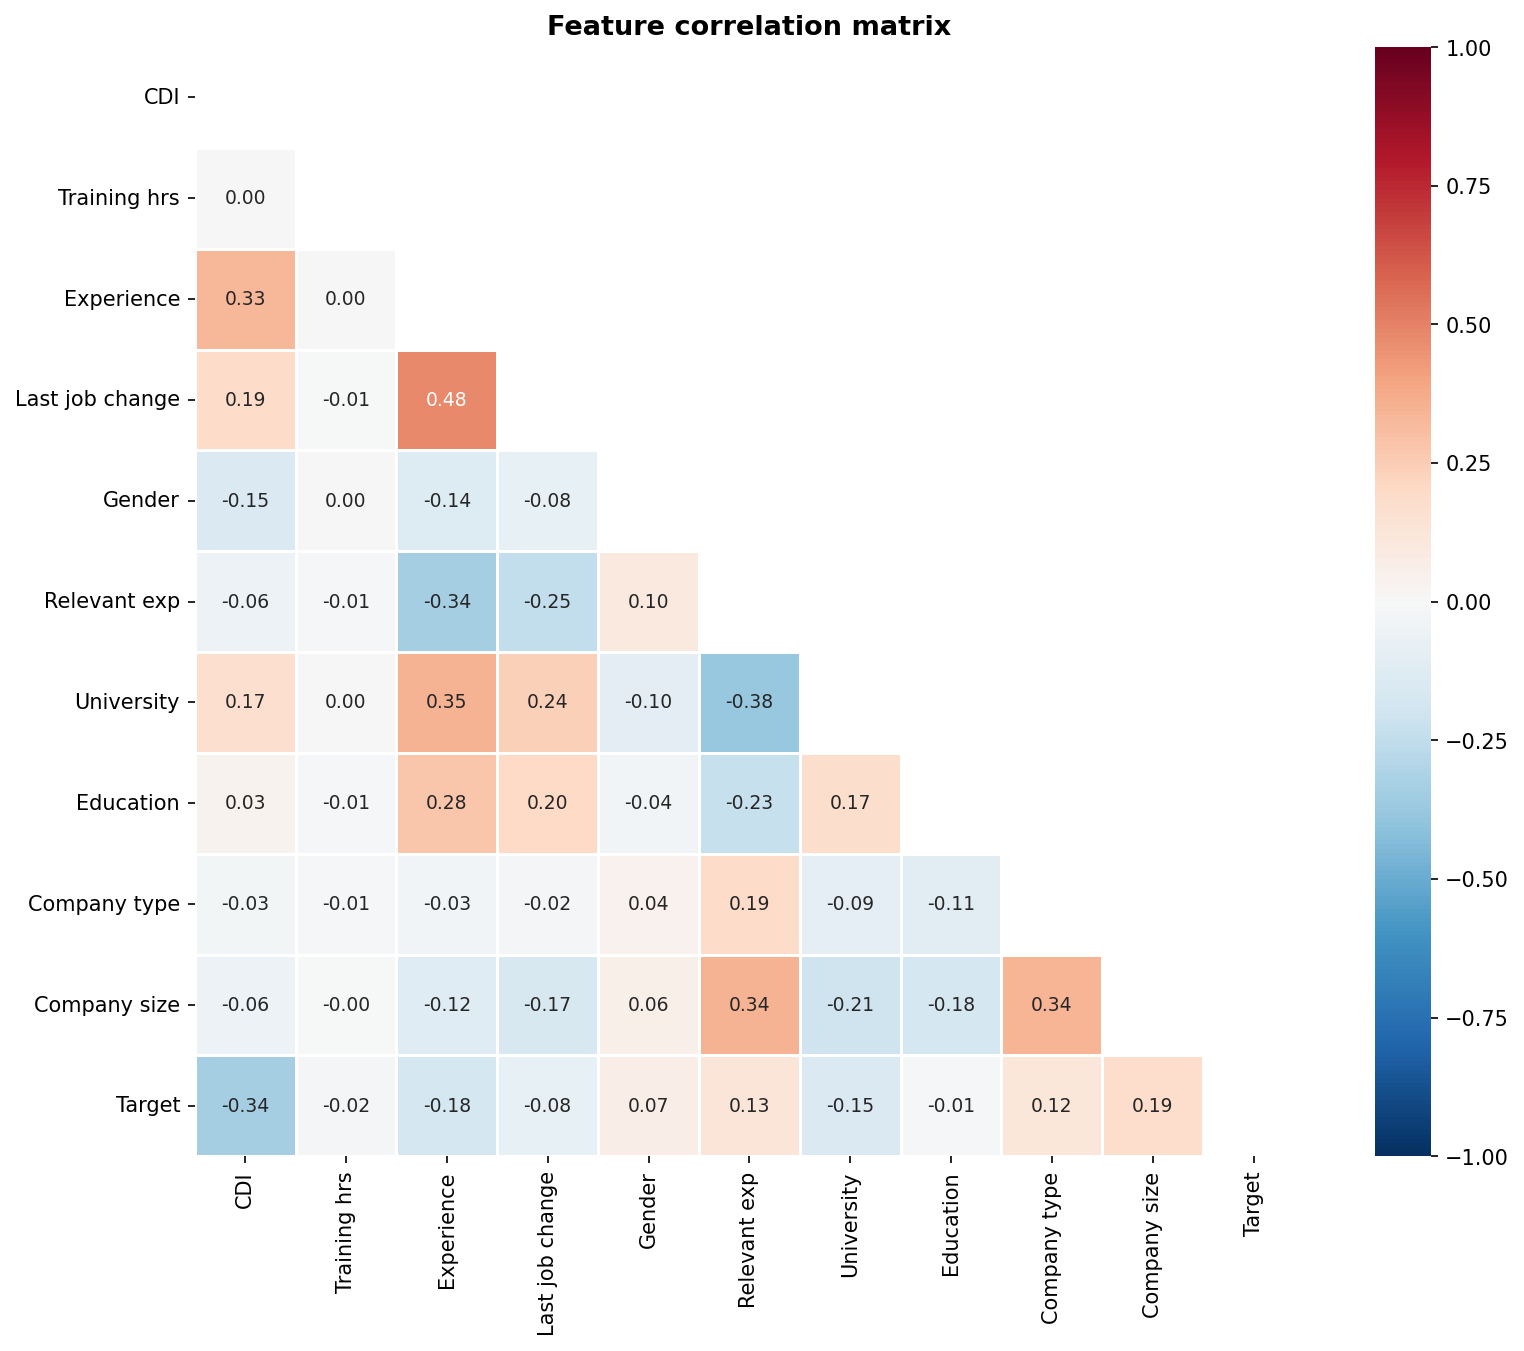

In [11]:
df_enc = train.copy()

exp_map = {'<1': 0, '>20': 21, **{str(i): i for i in range(1, 21)}}
lnj_map = {'never': 0, '>4': 5, **{str(i): i for i in range(1, 5)}}
edu_map = {'Primary School': 1, 'High School': 2, 'Graduate': 3, 'Masters': 4, 'Phd': 5}

df_enc['experience_num']   = df_enc['experience'].map(exp_map)
df_enc['last_new_job_num'] = df_enc['last_new_job'].map(lnj_map)
df_enc['education_num']    = df_enc['education_level'].map(edu_map)

for col in ['gender', 'relevent_experience', 'enrolled_university',
            'major_discipline', 'company_type', 'company_size']:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].fillna('Unknown'))

corr_cols = ['city_development_index', 'training_hours', 'experience_num',
             'last_new_job_num', 'gender_enc', 'relevent_experience_enc',
             'enrolled_university_enc', 'education_num',
             'company_type_enc', 'company_size_enc', 'target']
corr_labels = ['CDI', 'Training hrs', 'Experience', 'Last job change',
               'Gender', 'Relevant exp', 'University', 'Education',
               'Company type', 'Company size', 'Target']

corr = df_enc[corr_cols].corr()
corr.columns = corr_labels
corr.index   = corr_labels

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/10_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

CDI and relevant experience show the strongest correlations with target. Training hours is near-zero with target (r ≈ 0.01), confirming the bivariate finding. No feature pair shows correlation above 0.8, so multicollinearity is not a concern for modeling.

### Experience × Company Type Heatmap

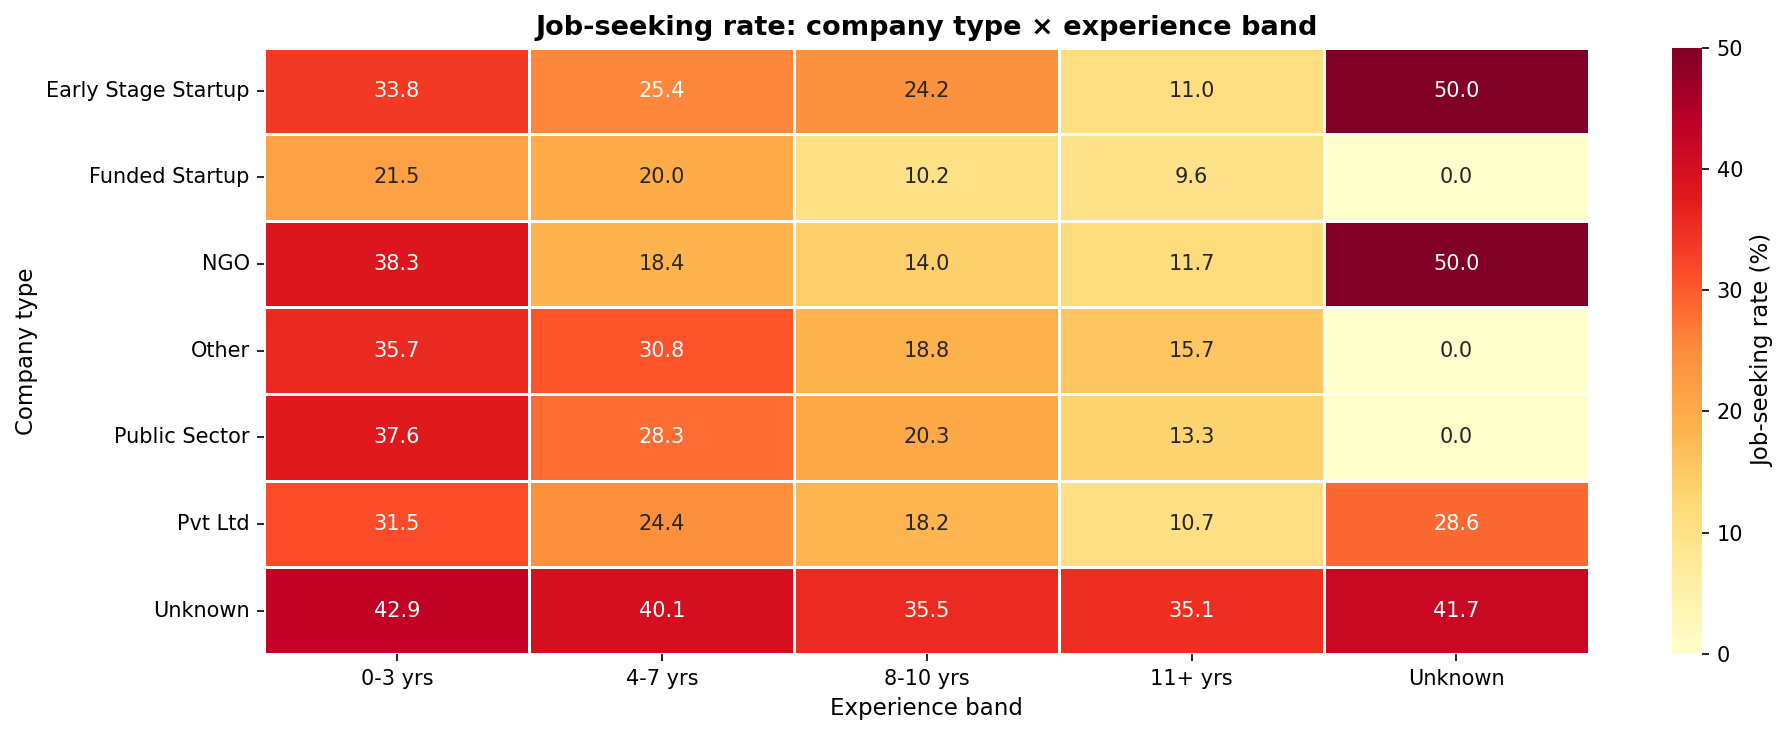

In [12]:
def bucket_exp(x):
    if pd.isna(x):             return 'Unknown'
    if x in ['<1','1','2','3']: return '0-3 yrs'
    if x in ['4','5','6','7']:  return '4-7 yrs'
    if x in ['8','9','10']:     return '8-10 yrs'
    return '11+ yrs'

pivot = (
    train.assign(
        exp_bucket=train['experience'].apply(bucket_exp),
        company_type=train['company_type'].fillna('Unknown')
    )
    .groupby(['company_type', 'exp_bucket'])['target']
    .mean()
    .unstack()
    .fillna(0) * 100
)

col_order = ['0-3 yrs', '4-7 yrs', '8-10 yrs', '11+ yrs', 'Unknown']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Job-seeking rate (%)'})
ax.set_title('Job-seeking rate: company type × experience band',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Experience band')
ax.set_ylabel('Company type')
plt.tight_layout()
plt.savefig('../outputs/figures/11_experience_company_type.png', bbox_inches='tight', dpi=150)
plt.show()

The darkest cells (highest attrition combinations) are early-career candidates (0-3 yrs) at companies with unknown type, and early-stage startups. This interaction effect is not visible in either feature alone, which is why the multivariate view matters.

---
## 6. Key Business Insights

### Insight 1 - City development index is the strongest attrition signal
Candidates from cities with CDI < 0.70 show a job-seeking rate ~1.9× higher than those in CDI > 0.90 cities. Limited local market opportunity drives external search behavior.
**HR action:** Adjust compensation benchmarking and offer remote-work flexibility for employees hired from lower-CDI markets.

---

### Insight 2 - The 2–4 year mark is the peak flight-risk window
Attrition intent peaks at 2–3 years of experience and declines steadily from year 5. This is the classic post-onboarding mobility window - enough skill to be attractive externally, not enough organizational investment to stay.
**HR action:** Structured career development conversations at 18 months and 30 months.

---

### Insight 3 - Company size is a strong stability proxy
Employees from companies with <10 staff show attrition rates above 35%. Enterprise employees (10,000+) show rates under 20%. Candidates coming from very small companies are a higher-risk hire for retention.
**HR action:** When recruiting from small companies, prioritize early onboarding investment and clear growth trajectory communication.

---

### Insight 4 - Training hours do not predict attrition (r ≈ 0.01)
There is virtually no correlation between training investment and attrition intent. Structural factors (CDI, company size, career stage) dominate completely.
**HR action:** Training budgets should be justified on skill-building grounds, not retention grounds.

---

### Insight 5 - Missing company data is a risk signal in itself
Candidates who did not report their company type or size have a seeking rate ~30-40% vs ~18-22% for those who did. This group likely includes freelancers and consultants who are structurally more mobile.
**HR action:** When recruiting candidates without company background information, apply higher retention effort during the first 12 months.